In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
housing=fetch_california_housing()

data=pd.DataFrame(housing.data,
columns=housing.feature_names)
data["Price"]=housing.target

In [6]:
x=data[['AveRooms']].values
y=data['Price'].values

In [7]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [8]:
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [45]:
w=0
b=0
cost_history=[]

learning_rate=0.001
epochs=1000
n=len(x_train_scaled)

for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        cost =  (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
        print(f"Epoch {i}, Cost = {cost:.4f}")
        cost_history.append(cost)
y_pred_gd = w * x_test_scaled.flatten() + b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 2.4226
Epoch 200, Cost = 2.1014
Epoch 300, Cost = 1.8385
Epoch 400, Cost = 1.6232
Epoch 500, Cost = 1.4470
Epoch 600, Cost = 1.3028
Epoch 700, Cost = 1.1847
Epoch 800, Cost = 1.0880
Epoch 900, Cost = 1.0089


In [46]:
print("Gradient Descent")
print("----------------")
print("Weight:",w)
print("Bias:",b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2 Score:",r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
Weight: 0.11586274243396351
Bias: 1.3101015281364523
MSE: 1.8452838282930013
R2 Score: -0.4081739815077585


In [47]:
# Normal equation

In [48]:
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)),x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne = x_test_ne @ theta

In [49]:
print("\nNormal Equation")
print("----------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))


Normal Equation
----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [50]:
# sort values for smooth regression

sort_axis = np.argsort(x_test.flatten())
x_sorted = x_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

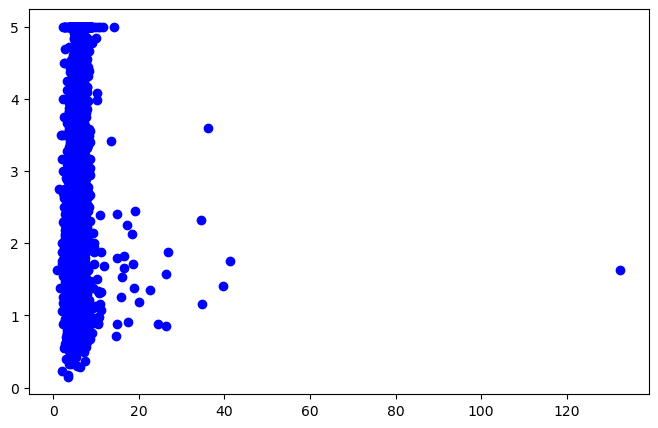

In [51]:
# line visualization

index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))

plt.scatter(x_test,y_test,color='blue',label='Actual Data')

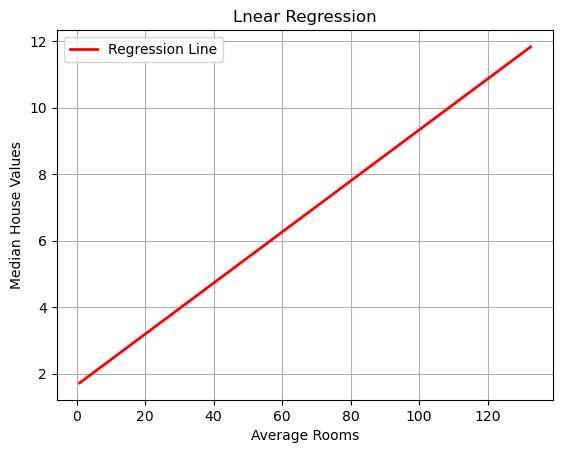

In [52]:
# Regression line

plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Lnear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Values")
plt.legend()
plt.grid(True)
plt.show()

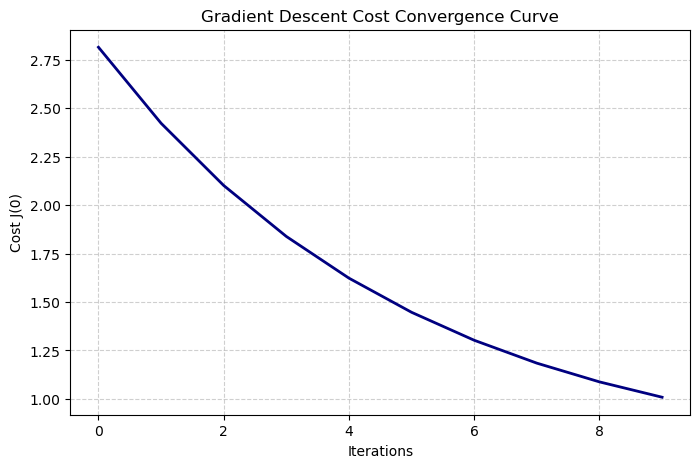

In [53]:
plt.figure(figsize=(8,5))

plt.plot(cost_history,color='navy',linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel("Cost J(0)")
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()